In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_excel("/content/startup-expansion.xlsx")
data.head()

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
0,1,Peoria,Arizona,Region 2,Old,2601,48610
1,2,Midland,Texas,Region 2,Old,2727,45689
2,3,Spokane,Washington,Region 2,Old,2768,49554
3,4,Denton,Texas,Region 2,Old,2759,38284
4,5,Overland Park,Kansas,Region 2,Old,2869,59887


In [ ]:
data.isna().sum()

,0
Store ID,0
City,0
State,0
Sales Region,0
New Expansion,0
Marketing Spend,0
Revenue,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Store ID         150 non-null    int64 
 1   City             150 non-null    object
 2   State            150 non-null    object
 3   Sales Region     150 non-null    object
 4   New Expansion    150 non-null    object
 5   Marketing Spend  150 non-null    int64 
 6   Revenue          150 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 8.3+ KB


In [ ]:
data.describe()

,Store ID,Marketing Spend,Revenue
count,150.000000,150.000000,150.000000
mean,75.500000,2893.146667,39301.433333
std,43.445368,367.862817,15465.753977
min,1.000000,1811.000000,15562.000000
25%,38.250000,2662.250000,21113.500000
50%,75.500000,2898.000000,42993.000000
75%,112.750000,3111.500000,51145.500000
max,150.000000,3984.000000,68828.000000


In [ ]:
data['City'].value_counts()

,count
City,
Rochester,2
Midland,1
Spokane,1
Denton,1
Peoria,1
...,...
Paterson,1
Brownsville,1
Rockford,1


In [ ]:
data['State'].value_counts()

,count
State,
California,40
Texas,17
Florida,12
Washington,7
Colorado,5
Illinois,5
New Jersey,4
Connecticut,4
Georgia,4


In [ ]:
data['State'].unique()

array(['Arizona', 'Texas', 'Washington', 'Kansas', 'New York', 'Alabama',
       'California', 'Massachusetts', 'New Mexico', 'Mississippi',
       'Oregon', 'Florida', 'Oklahoma', 'New Jersey', 'Utah', 'Colorado',
       'Michigan', 'South Carolina', 'Virginia', 'Ohio', 'New Hampshire',
       'Connecticut', 'Iowa', 'Arkansas', 'Tennessee', 'North Carolina',
       'Georgia', 'Illinois', 'Montana', 'Indiana', 'South Dakota',
       'Louisiana', 'Minnesota', 'Wisconsin', 'Rhode Island'],
      dtype=object)

In [ ]:
data['New Expansion'].value_counts()

,count
New Expansion,
Old,140
New,10


In [ ]:
data.sample(10)

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
142,143,Joliet,Illinois,Region 1,New,3279,48315
113,114,Renton,Washington,Region 2,Old,2754,44635
51,52,Fullerton,California,Region 2,Old,3246,44223
141,142,Tempe,Arizona,Region 2,New,2911,48954
76,77,West Valley City,Utah,Region 2,Old,2555,49609
61,62,Simi Valley,California,Region 2,Old,2792,41110
27,28,Salt Lake City,Utah,Region 2,Old,3620,56921
123,124,Daly City,California,Region 2,Old,2658,20703
29,30,Edison,New Jersey,Region 1,Old,3131,22972
105,106,Richardson,Texas,Region 2,Old,3228,22824


<Axes: xlabel='Sales Region'>

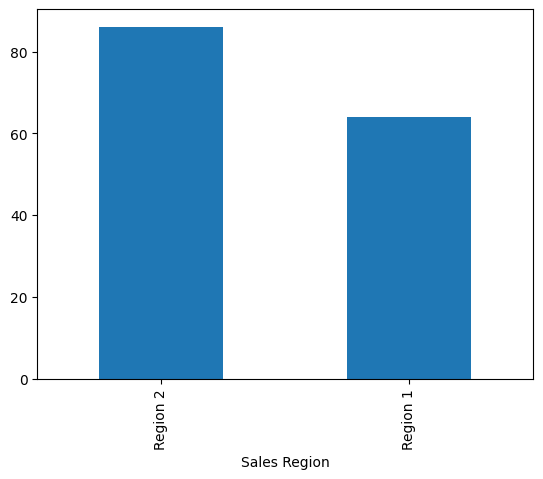

In [ ]:
data["Sales Region"].value_counts().plot.bar()

In [ ]:
data.groupby("State")["Revenue"].aggregate("sum")

,Revenue
State,
Alabama,221025
Arizona,131211
Arkansas,68828
California,1504351
Colorado,156495
Connecticut,158511
Florida,479023
Georgia,157656
Illinois,200413


In [ ]:
data["Profit"] = data["Revenue"] - data["Marketing Spend"]
data

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue,Profit
0,1,Peoria,Arizona,Region 2,Old,2601,48610,46009
1,2,Midland,Texas,Region 2,Old,2727,45689,42962
2,3,Spokane,Washington,Region 2,Old,2768,49554,46786
3,4,Denton,Texas,Region 2,Old,2759,38284,35525
4,5,Overland Park,Kansas,Region 2,Old,2869,59887,57018
...,...,...,...,...,...,...,...,...
145,146,Paterson,New Jersey,Region 1,New,2251,34603,32352
146,147,Brownsville,Texas,Region 2,New,3675,63148,59473
147,148,Rockford,Illinois,Region 1,New,2648,43377,40729
148,149,College Station,Texas,Region 2,New,2994,22457,19463


In [ ]:
data['ROMS%'] = round(data['Profit']/data["Marketing Spend"],2)
data

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue,Profit,ROMS%
0,1,Peoria,Arizona,Region 2,Old,2601,48610,46009,17.69
1,2,Midland,Texas,Region 2,Old,2727,45689,42962,15.75
2,3,Spokane,Washington,Region 2,Old,2768,49554,46786,16.90
3,4,Denton,Texas,Region 2,Old,2759,38284,35525,12.88
4,5,Overland Park,Kansas,Region 2,Old,2869,59887,57018,19.87
...,...,...,...,...,...,...,...,...,...
145,146,Paterson,New Jersey,Region 1,New,2251,34603,32352,14.37
146,147,Brownsville,Texas,Region 2,New,3675,63148,59473,16.18
147,148,Rockford,Illinois,Region 1,New,2648,43377,40729,15.38
148,149,College Station,Texas,Region 2,New,2994,22457,19463,6.50


In [ ]:
data[data["New Expansion"]== "Old"]


,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue,Profit,ROMS%
0,1,Peoria,Arizona,Region 2,Old,2601,48610,46009,17.69
1,2,Midland,Texas,Region 2,Old,2727,45689,42962,15.75
2,3,Spokane,Washington,Region 2,Old,2768,49554,46786,16.90
3,4,Denton,Texas,Region 2,Old,2759,38284,35525,12.88
4,5,Overland Park,Kansas,Region 2,Old,2869,59887,57018,19.87
...,...,...,...,...,...,...,...,...,...
135,136,San Mateo,California,Region 2,Old,1811,19426,17615,9.73
136,137,Warren,Michigan,Region 1,Old,2736,47262,44526,16.27
137,138,Norwalk,California,Region 2,Old,3112,19703,16591,5.33
138,139,Lafayette,Louisiana,Region 1,Old,2603,40255,37652,14.46


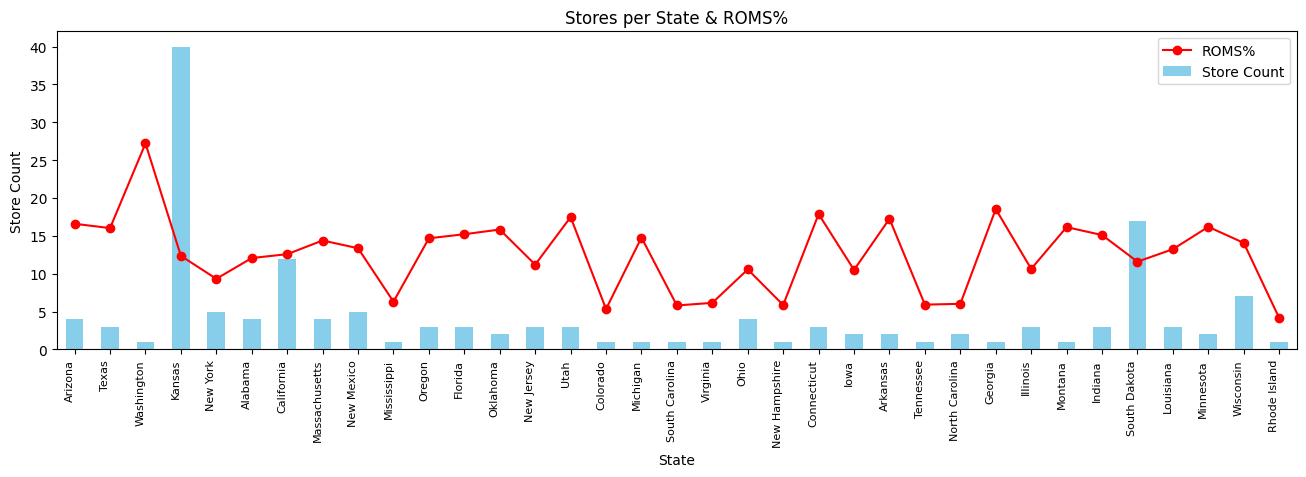

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

data.groupby("State")["Store ID"].count().plot.bar(
    ax=ax,
    color='skyblue',
    legend=False
)

roms_mean = data.groupby("State")["ROMS%"].mean()
roms_mean.plot.line(
    ax=ax,
    color='red',
    marker='o',
    legend=True
)

ax.set_ylabel("Store Count")
ax.set_title("Stores per State & ROMS%")
ax.legend(["ROMS%", "Store Count"])

ax.set_xticklabels(
    data["State"].unique(),
    rotation=90,
    ha='right',
    fontsize=8,
    fontweight='normal'
)

plt.subplots_adjust(bottom=0.35)

plt.savefig("stores_roms_by_state.png", dpi=300, bbox_inches="tight")

plt.show()
